## Data Collection, Cleaning and Preprocessing

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Display the first 5 rows and basic info
print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### Data Cleaning

In [2]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# For the Iris dataset, there are typically no missing values.
# If there were, we could impute them or drop rows/columns.
# Example: df.fillna(df.mean(), inplace=True)


Missing values per column:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


### Data Preprocessing

In [3]:
# Map target species to names for better readability
# The target column 'species' is already numerical (0, 1, 2)
# but for interpretability, let's add a column with actual names
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
display(df.head())

# Separate features (X) and target (y)
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


### Feature Scaling

Apply StandardScaler to normalize the feature columns. This is important for many machine learning algorithms, especially those that rely on distance metrics.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled data back to DataFrame for easier inspection (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("First 5 rows of scaled X_train:")
display(X_train_scaled_df.head())

First 5 rows of scaled X_train:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
98,-0.900459,-1.220248,-0.441986,-0.136610
68,0.380366,-1.879558,0.402829,0.380294
19,-0.900459,1.636764,-1.286801,-1.170419
143,1.078998,0.318143,1.191323,1.414103
99,-0.201827,-0.560937,0.177545,0.121842


## Exploratory Data Analysis (EDA)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

print("Descriptive statistics of the dataset:")
display(df.describe())

Descriptive statistics of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Pairplot to visualize relationships between features

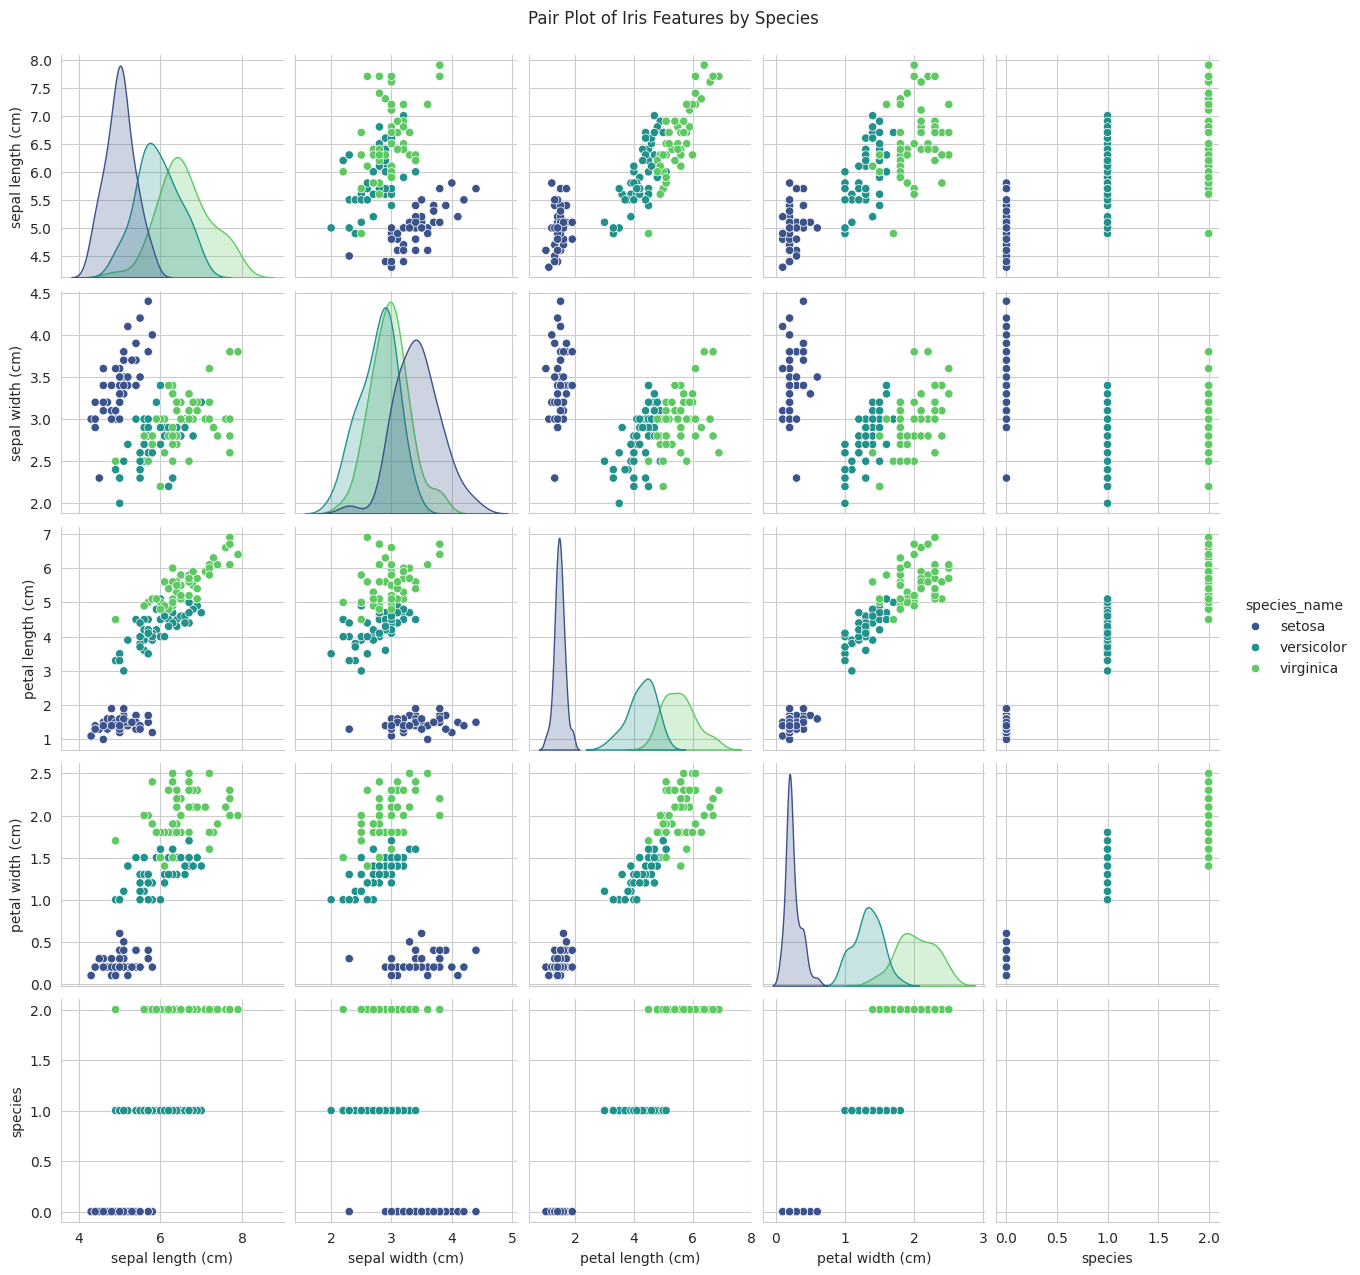

In [6]:
# Create a pairplot to visualize the relationships between features and species
sns.pairplot(df, hue='species_name', palette='viridis')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust suptitle position
plt.show()

### Histograms for each feature

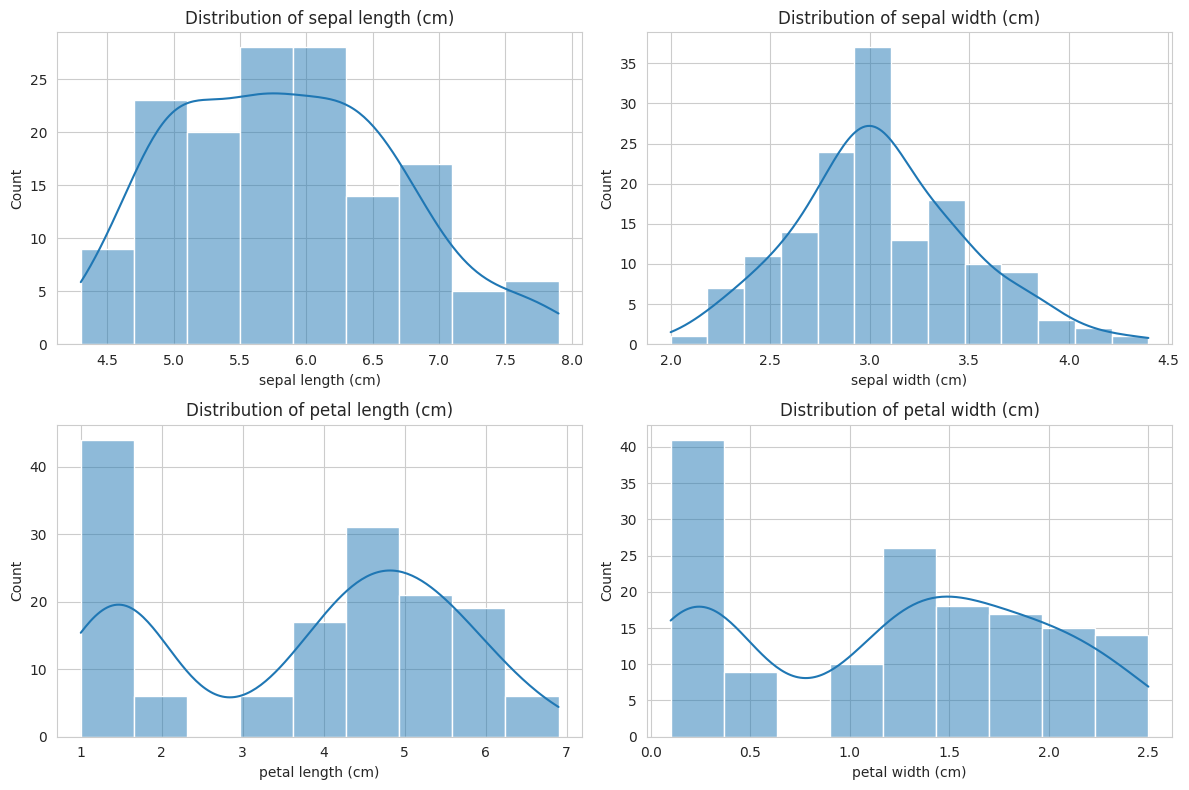

In [7]:
# Histograms for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feature in enumerate(X.columns):
    row = i // 2
    col = i % 2
    sns.histplot(df[feature], kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

### Box plots to show feature distribution by species

/tmp/ipykernel_1679/2930237005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature, data=df, ax=axes[row, col], palette='viridis')
/tmp/ipykernel_1679/2930237005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature, data=df, ax=axes[row, col], palette='viridis')
/tmp/ipykernel_1679/2930237005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature, data=df, ax=axes[row, col], palette='viridis')
/tmp/ipykernel_1679/2930237005.py:6: FutureWarning: 

Passing `palette

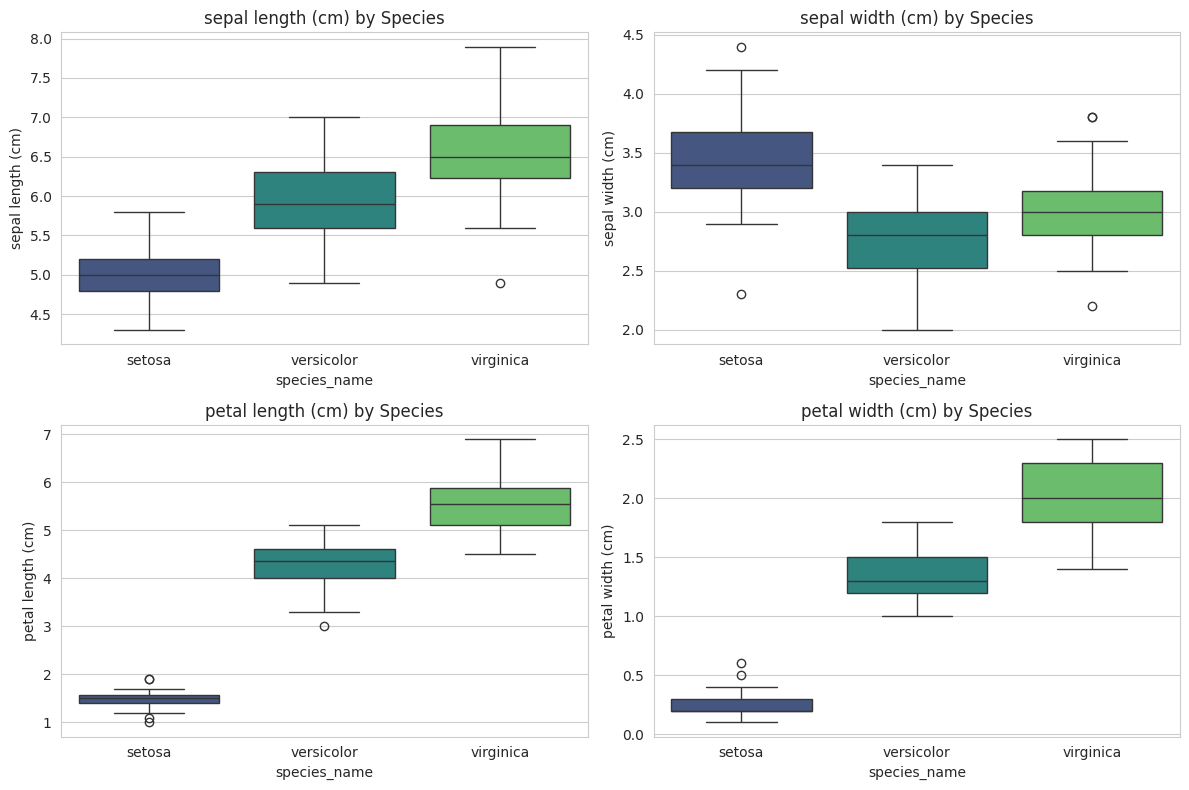

In [8]:
# Box plots for each feature grouped by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feature in enumerate(X.columns):
    row = i // 2
    col = i % 2
    sns.boxplot(x='species_name', y=feature, data=df, ax=axes[row, col], palette='viridis')
    axes[row, col].set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

### Correlation Matrix

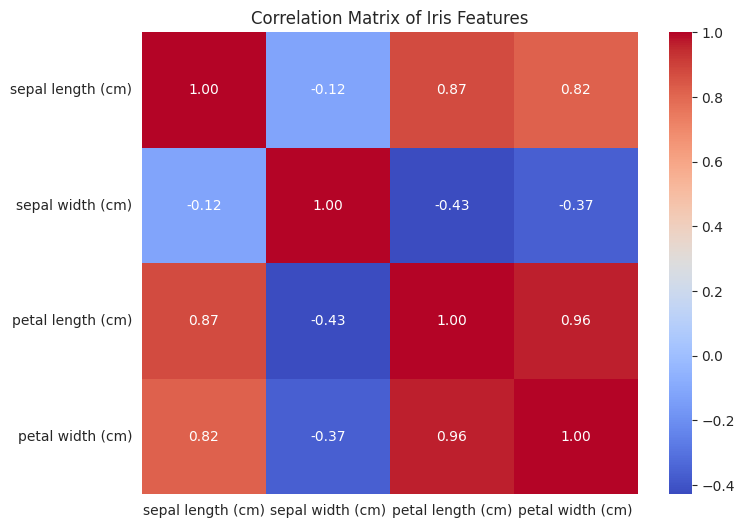

In [9]:
# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Iris Features')
plt.show()

## Model Training and Evaluation

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}
best_model_name = None
best_accuracy = 0

print("Training and evaluating models...")
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    display(pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names))

    # Check for the best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\nThe best model is: {best_model_name} with an accuracy of {best_accuracy:.4f}")

Training and evaluating models...

--- Logistic Regression ---
Accuracy: 0.8000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.75      0.60      0.67        15
           2       0.67      0.80      0.73        15

    accuracy                           0.80        45
   macro avg       0.81      0.80      0.80        45
weighted avg       0.81      0.80      0.80        45

Confusion Matrix:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,9,6
virginica,0,3,12



--- Decision Tree ---
Accuracy: 0.9111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.92      0.80      0.86        15
           2       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Confusion Matrix:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,12,3
virginica,0,1,14



--- Random Forest ---
Accuracy: 0.8889
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.78      0.93      0.85        15
           2       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45

Confusion Matrix:


...


--- Support Vector Machine ---
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Confusion Matrix:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,14,1
virginica,0,2,13



--- K-Nearest Neighbors ---
Accuracy: 0.9111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45

Confusion Matrix:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,15,0
virginica,0,4,11



The best model is: Support Vector Machine with an accuracy of 0.9333


### Save the Best Model and Scaler

In [11]:
# Save the best model
best_model = results[best_model_name]['model']
model_filename = 'iris_best_model.joblib'
joblib.dump(best_model, model_filename)
print(f"Best model ({best_model_name}) saved as {model_filename}")

# It's also crucial to save the scaler used for preprocessing
scaler_filename = 'iris_scaler.joblib'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as {scaler_filename}")

# Optional: Save target names for later use in the Streamlit app
target_names_filename = 'iris_target_names.joblib'
joblib.dump(iris.target_names.tolist(), target_names_filename)
print(f"Target names saved as {target_names_filename}")

Best model (Support Vector Machine) saved as iris_best_model.joblib
Scaler saved as iris_scaler.joblib
Target names saved as iris_target_names.joblib


## Create Streamlit Application

Below is the code for a Streamlit application (`streamlit_app.py`). You will need to save this code to a file named `streamlit_app.py` in the same directory as your saved model (`iris_best_model.joblib`), scaler (`iris_scaler.joblib`), and target names (`iris_target_names.joblib`).

To run the Streamlit application, open a terminal or command prompt, navigate to the directory where you saved the file, and execute the command:
`streamlit run streamlit_app.py`

In [12]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained model, scaler, and target names
# Make sure these files are in the same directory as your Streamlit app or provide the full path
try:
    model = joblib.load('iris_best_model.joblib')
    scaler = joblib.load('iris_scaler.joblib')
    target_names = joblib.load('iris_target_names.joblib')
except FileNotFoundError:
    st.error("Error: Model, scaler, or target names file not found. Please ensure 'iris_best_model.joblib', 'iris_scaler.joblib', and 'iris_target_names.joblib' are in the same directory as this app.")
    st.stop()

st.set_page_config(page_title="Iris Species Predictor", layout="centered")

st.title("🌸 Iris Species Predictor")
st.write("Enter the measurements of an Iris flower to predict its species.")

st.sidebar.header('Flower Measurements (cm)')

def user_input_features():
    sepal_length = st.sidebar.slider('Sepal Length', 4.3, 7.9, 5.4)
    sepal_width = st.sidebar.slider('Sepal Width', 2.0, 4.4, 3.4)
    petal_length = st.sidebar.slider('Petal Length', 1.0, 6.9, 1.3)
    petal_width = st.sidebar.slider('Petal Width', 0.1, 2.5, 0.2)
    data = {'sepal length (cm)': sepal_length,
            'sepal width (cm)': sepal_width,
            'petal length (cm)': petal_length,
            'petal width (cm)': petal_width}
    features = pd.DataFrame(data, index=[0])
    return features

df_input = user_input_features()

st.subheader('User Input Measurements')
st.write(df_input)

# Scale the input features
scaled_input = scaler.transform(df_input)
scaled_input_df = pd.DataFrame(scaled_input, columns=df_input.columns)

st.subheader('Scaled Input Features')
st.write(scaled_input_df)

# Make prediction
prediction_proba = model.predict_proba(scaled_input)
prediction = model.predict(scaled_input)

st.subheader('Prediction')
predicted_species = target_names[prediction[0]]
st.write(f"The predicted Iris species is: **{predicted_species}**")

st.subheader('Prediction Probability')
proba_df = pd.DataFrame(prediction_proba, columns=target_names)
st.write(proba_df)

st.write("--- Developed by your AI Assistant --- ")


Writing streamlit_app.py


## Generate `requirements.txt`

In [ ]:
import pkg_resources

# List of packages used in the notebook
packages = [
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'joblib',
    'streamlit'
]

# Collect package versions
requirements = []
for pkg in packages:
    try:
        version = pkg_resources.get_distribution(pkg).version
        requirements.append(f"{pkg}=={version}")
    except pkg_resources.DistributionNotFound:
        requirements.append(f"# {pkg} not found, please install manually if needed")

# Write to requirements.txt
with open('requirements.txt', 'w') as f:
    for req in requirements:
        f.write(req + '\n')

print("Generated requirements.txt:")
!cat requirements.txt

In [14]:
print('Installing required packages...')
!pip install -q -r requirements.txt
print('Packages installed successfully.')

Installing required packages...
Packages installed successfully.


Now that all the dependencies are installed, please try running your Streamlit application again from your terminal or command prompt by executing:
`streamlit run streamlit_app.py`